In [1]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
from scqubits import *
import numpy as np

In [2]:
EC = 1.46
EL = 0.23
EJ = 10

def get_estimations(EC, EL):
    try:
        qubit_level = 25

        qbt = Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
        evals = qbt.eigenvals()

        results = (evals[2]-evals[1], # qubit freq, want 10 MHz
                   evals[3]-evals[0], # drive feq
                   evals[4]-evals[1], 
                   evals[5]-evals[2]
                )
        results = tuple(x if np.shape(x) == () else None for x in results)
        return results

    except Exception as e:
        return (None, None, None,
                 None)

In [6]:
EC_subdivisions = 100
EL_subdivisions = 100
EC_values = np.linspace(0.1,3.5, EC_subdivisions)
EL_values = np.linspace(0.05, 0.75, EL_subdivisions)

EC_grid,EL_grid = np.meshgrid(EC_values, EL_values)

EC_flat = EC_grid.flatten()
EL_flat = EL_grid.flatten()

results = np.vectorize(get_estimations)(EC_flat, EL_flat)

In [9]:

num_elements_in_result = 4 #number of values produced for one set of parameters.
shape_of_grid = (EC_subdivisions, EL_subdivisions)
list_of_grid = [np.zeros(shape_of_grid,dtype=np.float32) for _ in range(num_elements_in_result)]
# Initialize counter for existing chunks
existing_chunk_num = 0


total_elements = EC_subdivisions* EL_subdivisions


# Initialize flattened arrays to store the results for this EJ value
list_of_flat = [np.zeros(total_elements) for _ in range(num_elements_in_result)]

# Place the results back into the flattened arrays
for idx, element in enumerate(results):
    list_of_flat[idx] = element


# Reshape the flattened arrays back into the original grid for this EJ value
for idx, grid in enumerate(list_of_grid):
    grid[ :, :] = list_of_flat[idx].reshape(shape_of_grid)


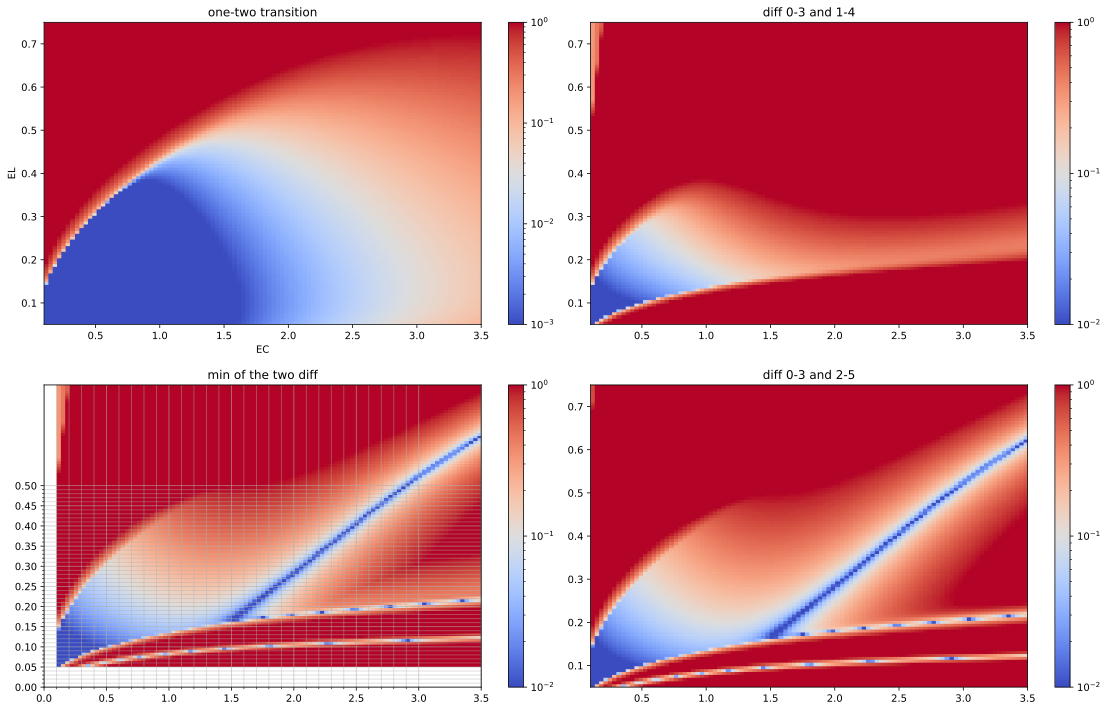

In [11]:
from matplotlib.colors import LogNorm, SymLogNorm
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

extent = (EC_values[0], EC_values[-1], EL_values[0], EL_values[-1])
qubit_freq_diff_norm = LogNorm(vmax = 1,vmin = 1e-2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# First subplot
im1 = axes[0, 0].imshow(list_of_grid[0][:, :], extent=extent, origin='lower', aspect='auto',
                        norm=LogNorm(vmax=1, vmin=1e-3), cmap='coolwarm')
fig.colorbar(im1, ax=axes[0, 0], label='')
axes[0, 0].set_title(f'one-two transition')
axes[0, 0].set_xlabel('EC')
axes[0, 0].set_ylabel('EL')

# Second subplot
im2 = axes[0, 1].imshow(abs(list_of_grid[1][:, :] - list_of_grid[2][:, :]), extent=extent,
                        origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im2, ax=axes[0, 1], label='')
axes[0, 1].set_title(f'diff 0-3 and 1-4')


# Third subplot
im3 = axes[1, 1].imshow(abs(list_of_grid[1][:, :] - list_of_grid[3][:, :]), extent=extent,
                        origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im3, ax=axes[1, 1], label='')
axes[1, 1].set_title(f'diff 0-3 and 2-5')


# Fourth subplot
im4 = axes[1, 0].imshow(np.minimum(abs(list_of_grid[1][:, :] - list_of_grid[2][:, :]),
                                  abs(list_of_grid[1][:, :] - list_of_grid[3][:, :])),
                        extent=extent, origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im4, ax=axes[1, 0], label='')
axes[1, 0].set_title(f'min of the two diff')
axes[1, 0].set_xticks(np.linspace(0, 3.5, 8))
axes[1, 0].set_xticks(np.linspace(0, 3, 31), minor=True)
axes[1, 0].set_yticks(np.linspace(0, 0.5, 11))
axes[1, 0].set_yticks(np.linspace(0, 0.5, 51), minor=True)
axes[1, 0].grid(which='minor', alpha=0.5)
axes[1, 0].grid(which='major', alpha=0.7)


plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.2)
plt.show()